# Practica de Laboratorio Nº2: Caracterizacion del ruido del canal inhalambrico.

In [ ]:
#---------------------------------------------------------------------------------
# Project    : Caracterizacion del ruido del canal inhalambrico
# Authors    : Brigido Tomas Andres, Lugones Oviedo Facundo Luis, Tosolini Agustin
# Affiliation: UNC
# E-mails    : tomas.brigido@mi.unc.edu.ar facundo.lugones.635@mi.unc.edu.ar agustin.tosolini@mi.unc.edu.ar
#---------------------------------------------------------------------------------

In [3]:
#! pip install pyadi-iio
#! pip install matplotlib
#! pip install scikit-dsp-comm
#! pip install scikit-commpy

Importamos las siguientes bibliotecas:

In [4]:
#------------------------------- Libraries ------------------------------- 
import adi
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from enum import Enum
from enum import StrEnum

esto permitirá tener acceso a distintas clases de Python, entre las cuales se encuentran las asociadas al SDR y a los AD936x. Con estas clases se pueden generar objetos cuyas propiedades van a ser utilizadas para reconfigurar el hardware en cuestión. 

Se definen los siguientes Enums para tener mayor claridad en la configuracion

In [5]:
class GainControlMode(StrEnum):
    SLOW_ATTACK = "slow_attack"
    FAST_ATTACK = "fast_attack"
    MANUAL      = "manual"

class LoopbackMode(Enum):
    DISABLED            = 0
    DIGITAL_LOOPBACK    = 1
    RETRANSMITTER       = 2

En las siguientes lineas de código se crea el objeto "sdr" y se lo vincula con el dispositivo que se encuentra en la dirección proporcionada por la variable "Uri".

In [6]:
Uri = "ip:192.168.1.32"
sdr = adi.Pluto(Uri)

## Parametros y configuración del SDR

In [7]:
#------------------------------- SDR Parameter Configuration -------------------------------#
SamplingRate    = 2.0e6                    # Sample rate RX and TX paths [Samples/Sec]
nSamples        = 2**20
frec            = SamplingRate/8

### Configuraciones necesarias para la experiencia. ###

Loopback         = 0  #
tx_cyclic_buffer = False
TxAtten          = -70      # Attenuation applied to TX path, valid range is -89 to 0 dB [dB]
GainControlModes = "manual" # Receive path AGC Options: slow_attack, fast_attack, manual

RxHardwareGain   = 70       # Gain applied to RX path. Only applicable when gain_control_mode is set to 'manual'    
RxBufferSize     = 2**20    # Rx Buffer size. Maximun value 2**28 [Samples]

### Configuraciones elegidas por el grupo. ###

TxLOFreq         = 1100e6        # Carrier frequency of TX path [Hz]
TxRfBw           = 2.0e6         # Bandwidth of front-end analog filter of TX path [Hz]

RxBufferSize     = nSamples      # Depend on the length of the transmit signal. Maximum tx buffer size 2**24[samples]
RxLOFreq         = 928e6      # Carrier frequency of RX path [Hz]
RxRfBw           = TxRfBw        # Bandwidth of front-end analog filter of RX path [Hz] 

In [8]:
### Realizacion de las configuraciones sobre el objeto sdr. ###

sdr.loopback = LoopbackMode.DISABLED.value
sdr.sample_rate = SamplingRate
# Filtros y TIA
sdr.tx_rf_bandwidth = int(TxRfBw)
sdr.rx_rf_bandwidth = int(RxRfBw)
# Ganancias de Hardware
sdr.tx_hardwaregain_chan0 = TxAtten
sdr.rx_hardwaregain_chan0 = RxHardwareGain
sdr.gain_control_mode_chan0 = GainControlMode.MANUAL.value
# Frecuencia de portadora
sdr.tx_lo = int(TxLOFreq)
sdr.rx_lo = int(RxLOFreq)
# Buffers
sdr.rx_buffer_size = RxBufferSize
sdr.tx_cyclic_buffer = tx_cyclic_buffer

## Recibiendo el ruido del canal inhalambrico
Las lineas de código que permiten recibir el ruido captado por el SDR son:

In [9]:
#------------------------------- Receptor ------------------------------- #
rxSignal = sdr.rx()

Se utilizan las siguientes formulas para calcular la media y la varianza en python.

Media:
$$ \mu = \frac{\sum_{i=1}^{N}x_i}{N}$$

Varianza:
$$ \sigma^2 = \frac{\sum_{i=1}^{N} (x-\mu)^2}{N} $$

In [10]:
# Se pasa a un vector de python para facilitar los calculos de la media y varianza
noise = list(rxSignal)
N = len(noise)

def media_muestral(data):
    acum = 0
    for ni in data:
        acum += ni
    return acum / len(data)

def varianza_muestral(data, media):
    acum2 = 0
    for ni in data:
        d = ni - media
        acum2 += abs(d) ** 2
    return acum2 / (len(data))

media = media_muestral(noise)
var_I = varianza_muestral(np.real(noise), np.real(media))
var_Q = varianza_muestral(np.imag(noise), np.imag(media))

# Varianza tipo MLE (divide por N)

print("Datos calculados con formula:")
print(f"Media I = {np.real(media)}; Media Q = {np.imag(media)}")
print(f"Varianza I = {var_I}; Varianza Q = {var_Q}")

Datos calculados con formula:
Media I = 0.009846687316894531; Media Q = 0.0011081695556640625
Varianza I = 110.18431790762403; Varianza Q = 111.31851264011557


Se realiza una comprobacion usando librerias nativas de numpy para corroborar que valores obtenidos son correctos.

In [11]:


# Para señal compleja:
mu_c = np.mean(noise)                               # media compleja
var_c_mle = np.mean(np.abs(noise - mu_c)**2)        # varianza (MLE, divide por N)

# Por componentes I/Q (útil para ruido en banda base)
I = np.real(noise)
Q = np.imag(noise)

mu_I = np.mean(I)
mu_Q = np.mean(Q)

var_I_np = np.var(I)   # divide por N
var_Q_np = np.var(Q)

print("\nDatos calulados con la libreria numpy:")
print(f"Media Real = {mu_I}; Media Imaginaria = {mu_Q}")
print(f"Var(Real) = {var_I_np}; Var(Imaginaria) = {var_Q_np}")

print("\nComparacion de los datos:")
print(f"Meida calculada con formula: {media}; Media calculada con NumPy: {mu_c}")
print(f"Varianza calculada con formula: {var_I+var_Q}; Varianza calculada con NumPy: {var_c_mle}")



Datos calulados con la libreria numpy:
Media Real = 0.009846687316894531; Media Imaginaria = 0.0011081695556640625
Var(Real) = 110.18431790633531; Var(Imaginaria) = 111.3185126421995

Comparacion de los datos:
Meida calculada con formula: (0.009846687316894531+0.0011081695556640625j); Media calculada con NumPy: (0.009846687316894531+0.0011081695556640625j)
Varianza calculada con formula: 221.50283054773962; Varianza calculada con NumPy: 221.5028305485348


Se observa que los valores son extremadamente similares, teniendo solo discrepancias alrededor de e-08 para el caso de la varianza, y para la media no se observan discrepancias.

## Histograma del Ruido

Definicion de la funcion de densidad de probabilidad gaussiana.

In [12]:
def gaussian_pdf(z, mu, var):
    return (1.0 / np.sqrt(2.0 * np.pi * var)) * np.exp(-((z - mu) ** 2) / (2.0 * var))

Codigo de python utilizado para graficar los histogramas

In [60]:
def plotHistWithGaussian(zI, zQ, mu_I_user, var_I_user, mu_Q_user, var_Q_user):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    # Histograma I + gaussiana manual
    ax[0].hist(I, bins=100, density=True, alpha=0.7, color="steelblue", label="Hist I")
    zI = np.linspace(np.min(I), np.max(I), 1000)
    ax[0].plot(zI, gaussian_pdf(zI, mu_I_user, var_I_user), "k", lw=2, label="Gauss manual")
    ax[0].set_title(f"I: mu={mu_I_user:.3g}, var={var_I_user:.3g}")
    ax[0].set_xlabel("Valor")
    ax[0].set_ylabel("Densidad")
    ax[0].grid(True, alpha=0.3)
    ax[0].legend()
    # Histograma Q + gaussiana manual
    ax[1].hist(Q, bins=100, density=True, alpha=0.7, color="tomato", label="Hist Q")
    zQ = np.linspace(np.min(Q), np.max(Q), 1000)
    ax[1].plot(zQ, gaussian_pdf(zQ, mu_Q_user, var_Q_user), "k", lw=2, label="Gauss manual")
    ax[1].set_title(f"Q: mu={mu_Q_user:.3g}, var={var_Q_user:.3g}")
    ax[1].set_xlabel("Valor")
    ax[1].set_ylabel("Densidad")
    ax[1].grid(True, alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    plt.show()


Codigo de Python donde se permite ingresar valores a mano para observa como cambia la Funcion de probabilidad de densidad gaussiana.

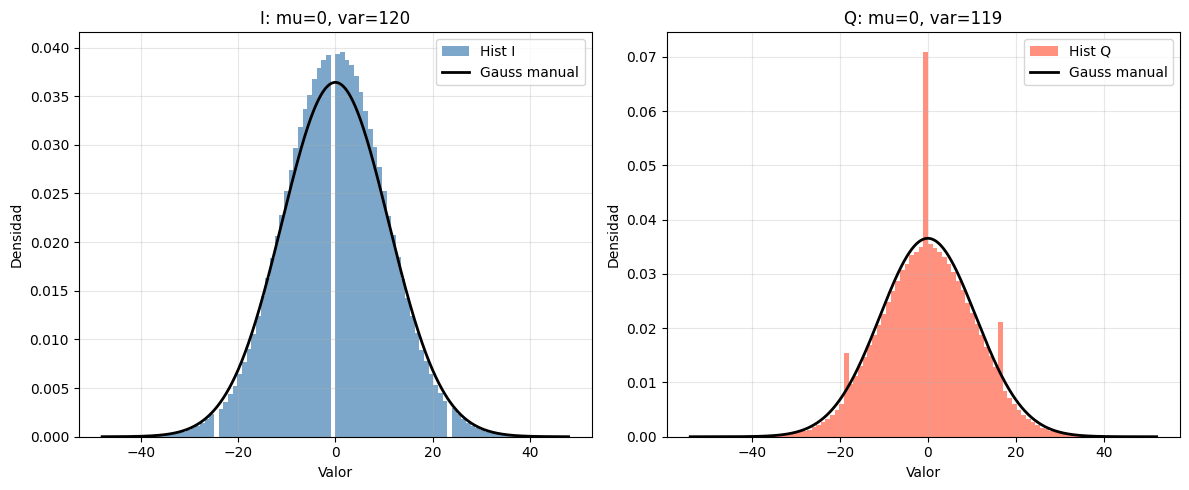

In [62]:
I = np.real(noise)
Q = np.imag(noise)

# -------------------- Parametros ajustables a mano --------------------
# Cambialos y volve a ejecutar la celda
mu_I_user  = 0
var_I_user = 120

mu_Q_user  = 0
var_Q_user = 119
# ---------------------------------------------------------------------

plotHistWithGaussian(I, Q, mu_I_user, var_I_user, mu_Q_user, var_Q_user)


## Grafico del ruido en el tiempo

Se reutiliza el siguiente codigo que fue presentado en "How To Config SDR" para graficar en el tiempo los valores obtenidos del ruido.

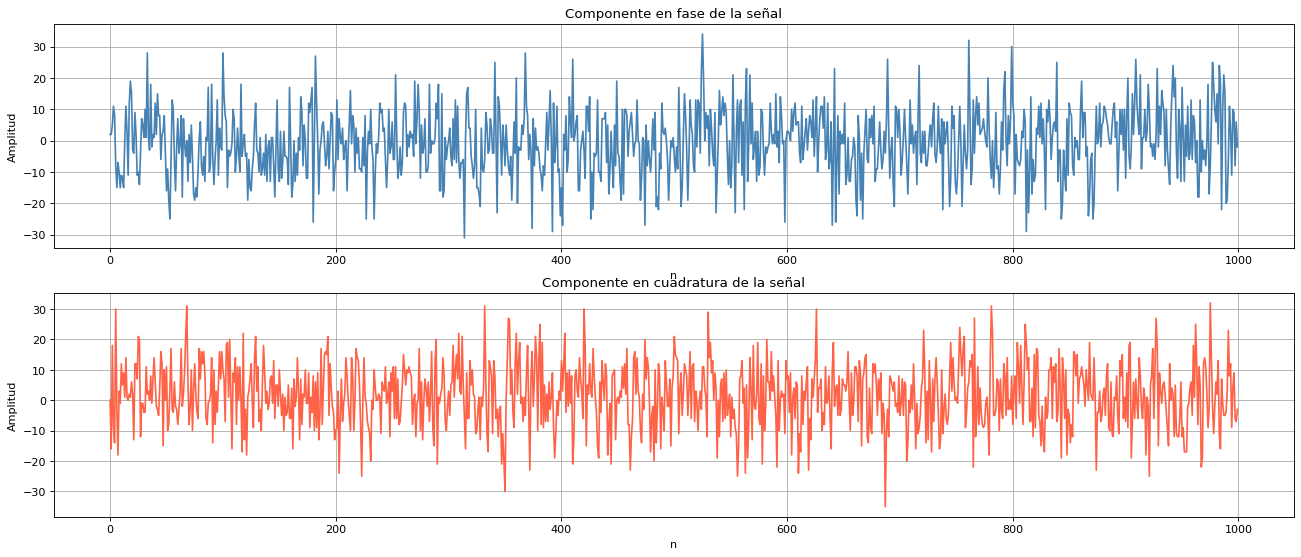

In [42]:

def plotSignal(signal):
#------------------------------- Transmitted I component ------------------------------- 
# Plot time domain
    plt.figure(figsize=(20,8), dpi= 80, facecolor='w', edgecolor='k')
    plt.subplot(2,1,1)
    plt.plot(np.real(signal), color='steelblue')
    plt.xlabel('n')
    plt.ylabel('Amplitud')
    plt.title('Componente en fase de la señal')
    plt.grid()
#------------------------------- Transmitted Q component -------------------------------
# Plot time domain
    plt.subplot(2,1,2)
    plt.plot(np.imag(signal), color='tomato')
    plt.xlabel('n')
    plt.ylabel('Amplitud')
    plt.title('Componente en cuadratura de la señal')
    plt.grid()
    plt.show()
    
plotSignal(rxSignal[0:1000])

## Gráfica de la densidad espectral de potencia del Ruido

Se reutiliza el siguiente codigo que fue presentado en "How To Config SDR" para graficar en el frecuencia los valores obtenidos del ruido.

/tmp/ipykernel_97227/3429850939.py:5: MatplotlibDeprecationWarning: Passing the NFFT parameter of psd() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.psd(signal, len(signal), samplingRate, color='C1')


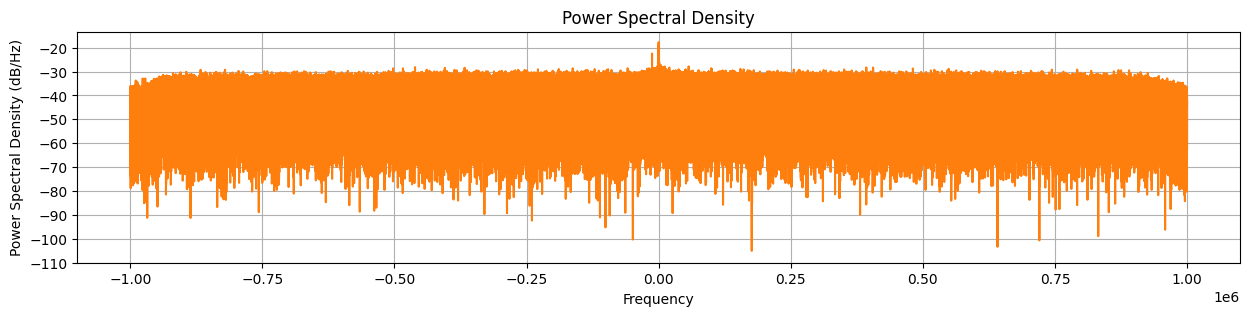

In [16]:
def plotSpect(signal,samplingRate):
    plt.subplots(figsize=(15, 3))
    plt.grid()
    plt.title("Power Spectral Density")
    plt.psd(signal, len(signal), samplingRate, color='C1')
    plt.show()
    
plotSpect(rxSignal,SamplingRate)

## Grafico QQ

Con el siguiente codigo de python se realiza un grafico QQ, este mismo es utilizado para ver de manera grafica la "gaussianidad" de la señal muestreada, los ejes representan la siguiente informacion:

1. Eje X (Cuantiles teóricos): Dónde deberían estar los puntos si la señal fuera una campana de Gauss perfecta.

2. Eje Y (Cuantiles de datos medidos): Dónde están realmente los datos ordenados de menor a mayor.

Es decir, dado estos ejes un "gaussianidad" perfecta se representa como la función identidad.

In [17]:
def plotQQ(I, Q):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # QQ plot para I
    stats.probplot(I, dist="norm", plot=ax[0])
    ax[0].set_title("QQ plot - Parte real (I)")
    ax[0].grid(True, alpha=0.3)

    # QQ plot para Q
    stats.probplot(Q, dist="norm", plot=ax[1])
    ax[1].set_title("QQ plot - Parte imaginaria (Q)")
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

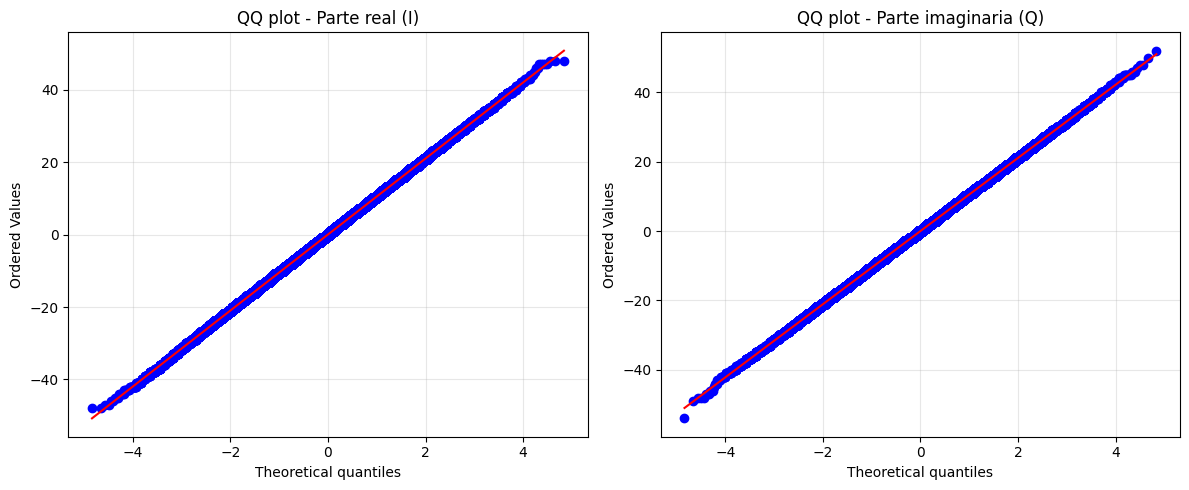

In [18]:
I = np.real(noise)
Q = np.imag(noise)

plotQQ(I, Q)


## Configuracion para desconectarse del SDR
Se deja configurado el transmisor con la máxima atenuación posible, para asegurarse que las frecuencias de transmisión y recepción no coinciden y cargar al Buffer transmisor con ceros. Esto permitirá minimizar cualquier posible interferencia por parte del SDR.

In [19]:
sdr.tx_destroy_buffer()
sdr.tx_hardwaregain_chan0 = -89 
sdr.tx_lo                 = int(2400e6)
sdr.rx_lo                 = int(950e6)
sdr.tx(np.zeros(2048))

In [20]:
# Destruyendo el objeto de radio.
del(sdr)

# Variable Gaussiana Temporal

En primera instancia se utilizaria las funciones de numpy "randn" para generar valores aleatorios con una distribucion normal, esto nos generaria una instancia del ruido con media cero y varianza unitaria $Z \sim N(0,1)$ para poder llevar esto a la media y varianza calculada necesitamos sumar la media y multiplicar ese resultado por la varianza, es decir se realiza la siguiente operacion sobre todos los valores generados por "randn".

$$ Z((x+\mu)*\sigma) $$

Luego se utilizan las funciones anteriormente definidas para realizar los graficos solicitados.

In [48]:
def plotHist(z):
    I_z = np.real(z)
    Q_z = np.imag(z)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(I_z, bins=100, density=True, alpha=0.7, color='steelblue')
    plt.title('Histograma de I sintética')
    plt.xlabel('Valor')
    plt.ylabel('Densidad')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(Q_z, bins=100, density=True, alpha=0.7, color='tomato')
    plt.title('Histograma de Q sintética')
    plt.xlabel('Valor')
    plt.ylabel('Densidad')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

mu_z = (141.27276966956052+212.08300390342583j)
var_z = 9991.0066185365  (objetivo: 221.5028305485348)


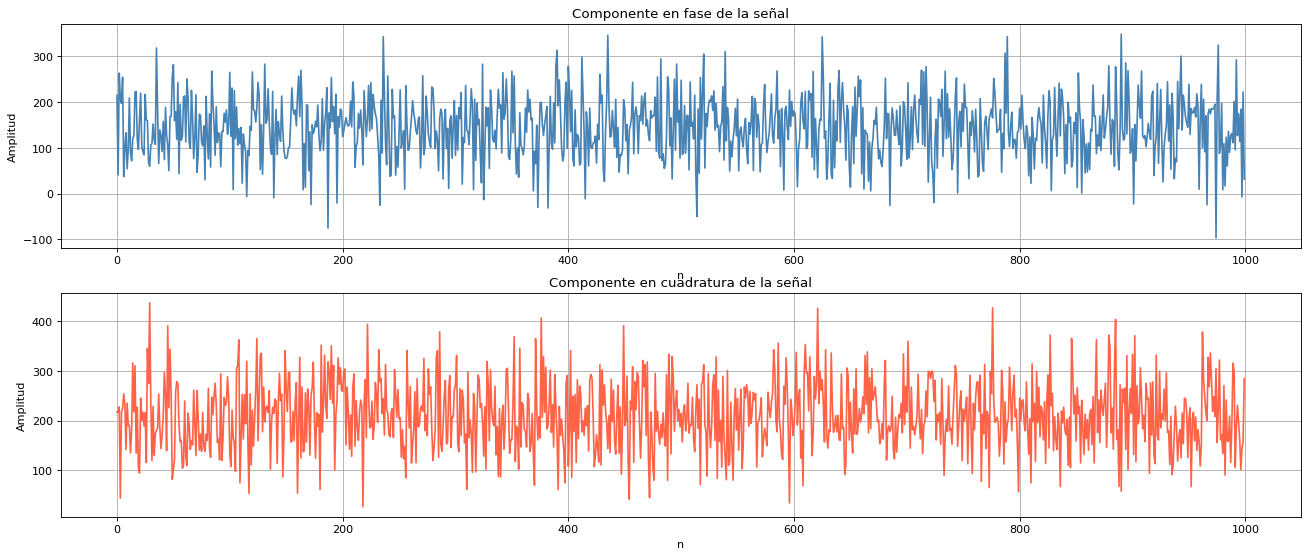

/tmp/ipykernel_97227/3429850939.py:5: MatplotlibDeprecationWarning: Passing the NFFT parameter of psd() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.psd(signal, len(signal), samplingRate, color='C1')


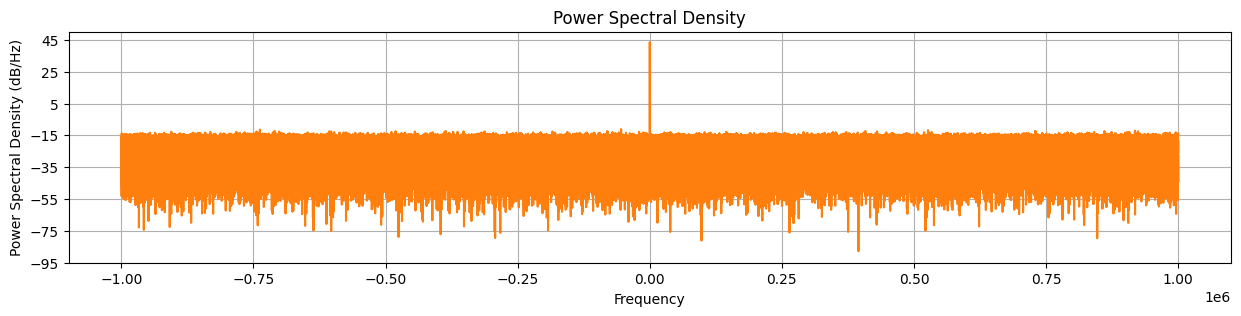

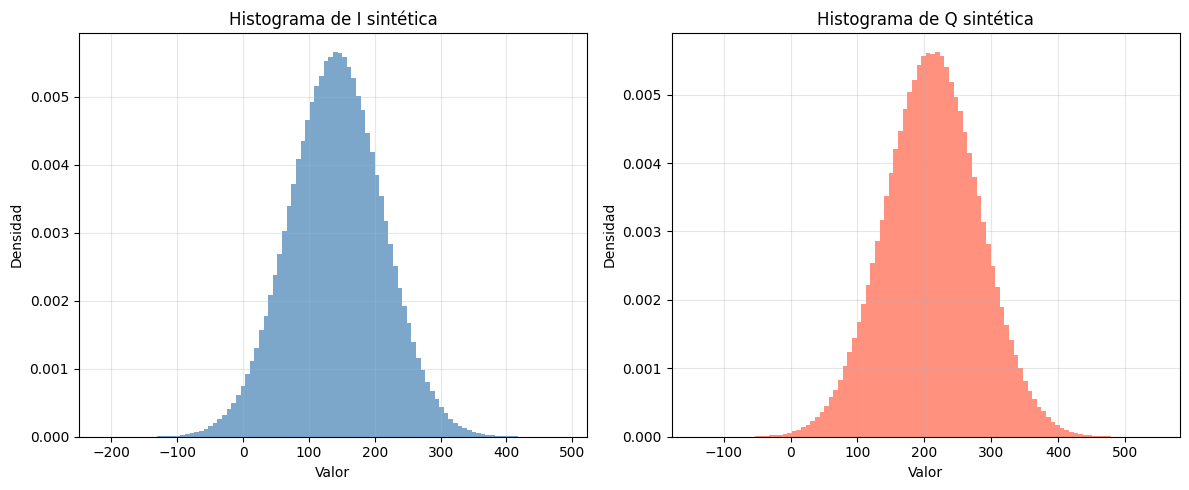

In [66]:
# Generar y analizar una señal gaussiana compleja usando valores fijos de la señal muestreada
N = nSamples

# Para ruido complejo circularmente simétrico:
# var_complex = var_I + var_Q = 2 * sigma^2
desviacion = np.sqrt(var_c_mle / 2)
desviacion = np.sqrt(10000 / 2)
# Conjunto de datos complejos que representa el ruido con la media y varianza calculada a partir de la señal muestreada.
z =  ((np.random.randn(N) + 1j * np.random.randn(N)) + mu_c) * desviacion
mu_z = np.mean(z)
var_z = np.var(z)
print(f"mu_z = {mu_z}")
print(f"var_z = {var_z}  (objetivo: {var_c_mle})")

# Gráfica temporal de las primeras muestras
plotSignal(z[:1000])

# Gráfica en frecuencia
plotSpect(z,SamplingRate)

# Histogramas de I y Q
plotHist(z)

# Conclusion

A partir de la configuración del PlutoSDR y de la adquisición de un bloque grande de muestras complejas, fue posible caracterizar el ruido presente en el canal inalámbrico desde una perspectiva temporal, espectral y estadística. En el procedimiento realizado se fijaron los parámetros principales del receptor, se capturaro el ruido con una determinada frecuencia de muestreo y se lo caracterizó mediante su media, su varianza.

Los resultados obtenidos muestran que la media compleja del ruido es cercana a cero, mientras que la varianza total medida se reparte de manera aproximadamente equilibrada entre las componentes I y Q. Este comportamiento es consistente con el modelo habitual de ruido aditivo gaussiano complejo en banda base, donde ambas componentes pueden interpretarse como variables aleatorias gaussianas de media cero y dispersión similar. Los histogramas y los QQ plots refuerzan esta interpretación, ya que permiten observar una forma aproximadamente normal para ambas componentes, aunque con pequeñas desviaciones esperables en una medición real sobre hardware.

Por otra parte, el análisis espectral de la señal recibida permite verificar que la energía del ruido se distribuye sobre la banda observada sin estructura determinística dominante, lo cual es coherente con un proceso esencialmente aleatorio e independiente. La comparación posterior con una señal gaussiana compleja sintética generada a partir de la media y la varianza estimadas resulta útil para validar y representar el modelo, ya que la señal simulada reproduce un comportamiento estadístico similar al de la medición experimental. Esto confirma que, para fines de modelado y simulación, el ruido medido puede aproximarse razonablemente mediante una variable gaussiana compleja simétrica.

En conclusión, la experiencia permite afirmar que el ruido captado por el sistema receptor puede describirse de forma satisfactoria mediante un modelo de ruido gaussiano blanco complejo, con media cero y una distribución espectral compatible con un proceso aleatorio. Esta caracterización es fundamental para etapas posteriores del trabajo en comunicaciones digitales, ya que proporciona un modelo realista del canal para evaluar el desempeño de sistemas frente al ruido.